# Hotel Booking Cancellation — EDA & Baseline

<div style="background-color:#1e293b;padding:15px;border-left:6px solid #38bdf8;color:#e2e8f0">

<b>EDA Checklist</b> — run through this for every new dataset

<ol>
<li>Check shape (rows, columns)</li>
<li>Check dtypes and flag unexpected types</li>
<li>Check missing values: count and %</li>
<li>Check distributions: numerical (histograms) and categorical (bar charts)</li>
<li>Check correlations with target</li>
<li>Identify potential issues: outliers, skewness, high-cardinality columns, data leakage</li>
</ol>

</div>

---
## Step 1: Setup and Loading Data

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

sns.set_palette('Set2')
plt.rcParams['figure.figsize'] = (10, 5)

RANDOM_SEED = 42

df = pd.read_csv('hotel_bookings.csv')
print('Shape:', df.shape)
df.head()

Shape: (95705, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,City Hotel,1,8,2016,May,20,10,0,2,1,...,No Deposit,7.0,NaN,0,Transient,108.57,0,1,Canceled,2016-05-09
1,City Hotel,1,91,2016,October,43,20,0,3,2,...,No Deposit,9.0,NaN,0,Transient,132.30,0,2,Canceled,2016-07-25
2,Resort Hotel,0,76,2016,August,34,16,2,5,2,...,No Deposit,250.0,NaN,0,Transient,216.43,0,0,Check-Out,2016-08-23
3,Resort Hotel,0,267,2017,April,14,8,3,6,2,...,No Deposit,250.0,NaN,0,Transient-Party,54.68,0,0,Check-Out,2017-04-17
4,City Hotel,1,31,2016,March,13,26,1,1,2,...,No Deposit,9.0,NaN,0,Transient,116.10,0,0,Canceled,2016-02-25


---
## Step 2: Data Profiling

In [ ]:
print('Shape:', df.shape)
print('\nColumn names:')
print(df.columns.tolist())
print('\nData types:')
print(df.dtypes)
print('\nMissing values:')
print(df.isnull().sum()[df.isnull().sum() > 0])

Shape: (95705, 32)

Column names:
['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'company', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'reservation_status', 'reservation_status_date']

Data types:
hotel                                 str
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                    str
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int6

### Missing values

In [ ]:
missing_count = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)

missing_report = pd.DataFrame({'missing_count': missing_count, 'missing_pct': missing_pct})

print('Columns with missing values:')
print(missing_report[missing_report['missing_count'] > 0])

Columns with missing values:
          missing_count  missing_pct
children              4         0.00
country             395         0.41
agent             13152        13.74
company           90134        94.18


> **Rule of thumb:** Under 5% missing is usually safe to handle with simple imputation or a missing indicator. 
> Over 30% missing in a column warrants serious thought — is the column worth keeping? Here, `company` is missing in ~94% of rows and `agent` in ~14%. So it's worth to drop `company` from the baseline and treat `agent` as optional.

### Summary statistics

In [ ]:
# Numerical columns
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,95705.000000,95705.000000,95705.000000,95705.000000,95705.000000,95705.000000,95705.000000,95705.000000,95701.000000,95705.000000,95705.000000,95705.000000,95705.000000,95705.000000,82553.000000,5571.000000,95705.000000,95705.000000,95705.000000,95705.000000
mean,0.371506,104.430092,2016.159208,27.129398,15.806583,0.929983,2.497727,1.853414,0.104189,0.007826,0.032130,0.089849,0.140108,0.221504,86.622582,189.963741,2.306400,101.628299,0.062233,0.571882
std,0.483210,106.848164,0.706967,13.615093,8.759088,0.997614,1.906128,0.550627,0.399976,0.098532,0.176346,0.873620,1.528274,0.653418,110.941624,132.061699,17.984215,51.132479,0.244075,0.793292
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,67.000000,0.000000,69.000000,0.000000,0.000000
50%,0.000000,70.000000,2016.000000,27.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,180.000000,0.000000,94.500000,0.000000,0.000000
75%,1.000000,161.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,125.290000,0.000000,1.000000
max,1.000000,709.000000,2017.000000,53.000000,31.000000,18.000000,42.000000,40.000000,10.000000,10.000000,1.000000,26.000000,72.000000,20.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [ ]:
# Categorical columns
df.describe(include='str')

,hotel,arrival_date_month,meal,country,market_segment,distribution_channel,reserved_room_type,assigned_room_type,deposit_type,customer_type,reservation_status,reservation_status_date
count,95705,95705,95705,95310,95705,95705,95705,95705,95705,95705,95705,95705
unique,2,12,5,169,8,5,10,12,3,4,3,920
top,City Hotel,August,BB,PRT,Online TA,TA/TO,A,A,No Deposit,Transient,Check-Out,2015-10-21
freq,63676,10973,74212,39038,45250,78478,68966,59409,83535,71999,60150,1182


### Target variable

In [ ]:
print('Cancellation counts:')
print(df['is_canceled'].value_counts())
print(f"\nCancellation rate: {df['is_canceled'].mean():.1%}")

Cancellation counts:
is_canceled
0    60150
1    35555
Name: count, dtype: int64

Cancellation rate: 37.2%


> **Note:** About 37% of bookings were canceled. A model that always predicts "not canceled" would be ~63% accurate without learning anything. Keep this in mind when reading accuracy numbers.

In [ ]:
print(f"Median lead_time: {df['lead_time'].median():.0f} days")
print(f"Mean lead_time:   {df['lead_time'].mean():.0f} days")
print(f"Max lead_time:    {df['lead_time'].max():.0f} days")
print(f"Unique countries: {df['country'].nunique()}")

Median lead_time: 70 days
Mean lead_time:   104 days
Max lead_time:    709 days
Unique countries: 169


The gap between mean (~104 days) and max (709 days) suggests a long right tail — a few bookings are made far in advance.

---
## Step 3: Numerical Distributions


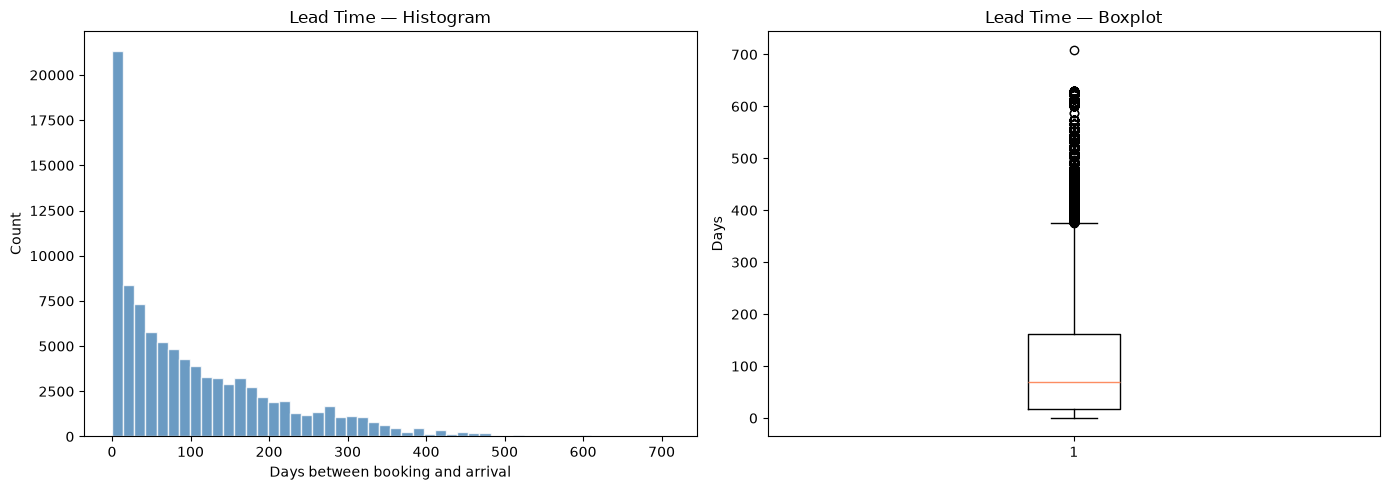

Mean:        104 days
Median:       70 days
Max:         709 days


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['lead_time'], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('Lead Time — Histogram')
axes[0].set_xlabel('Days between booking and arrival')
axes[0].set_ylabel('Count')

axes[1].boxplot(df['lead_time'])
axes[1].set_title('Lead Time — Boxplot')
axes[1].set_ylabel('Days')

plt.tight_layout()
plt.show()

print(f"Mean:   {df['lead_time'].mean():>8.0f} days")
print(f"Median: {df['lead_time'].median():>8.0f} days")
print(f"Max:    {df['lead_time'].max():>8.0f} days")

**Observations:**
- Most bookings are made within a few months of arrival (median ~70 days)
- A long right tail exists — so we can conclude that some guests book one year in advance.
- Long lead times are a strong signal for cancellation

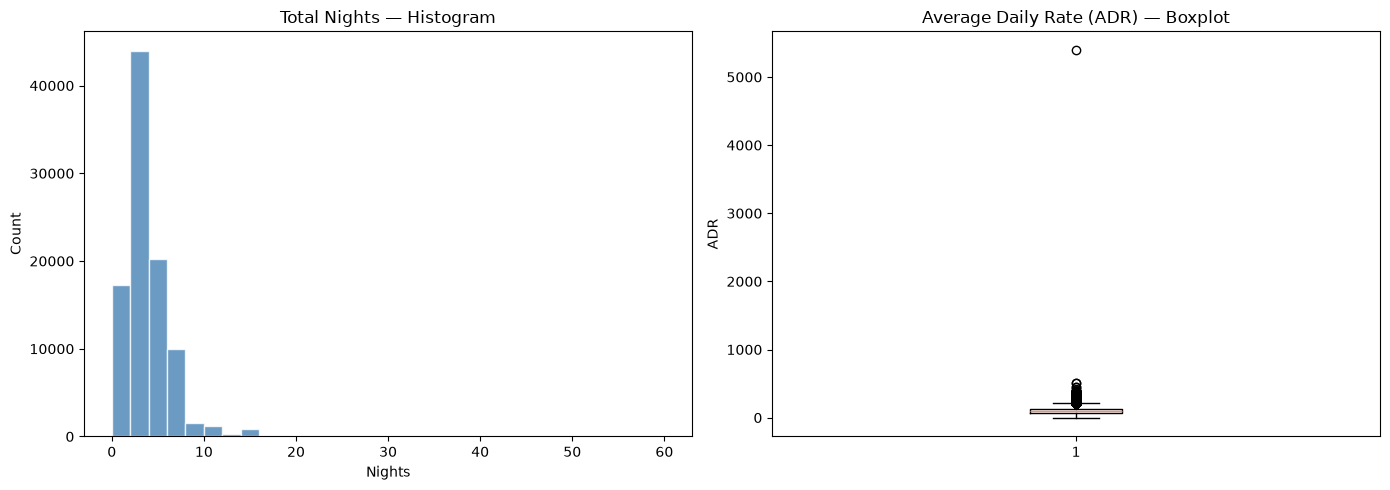

In [ ]:
df['total_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['total_nights'], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('Total Nights — Histogram')
axes[0].set_xlabel('Nights')
axes[0].set_ylabel('Count')

axes[1].boxplot(df['adr'],)
axes[1].set_title('Average Daily Rate (ADR) — Boxplot')
axes[1].set_ylabel('ADR')

plt.tight_layout()
plt.show()

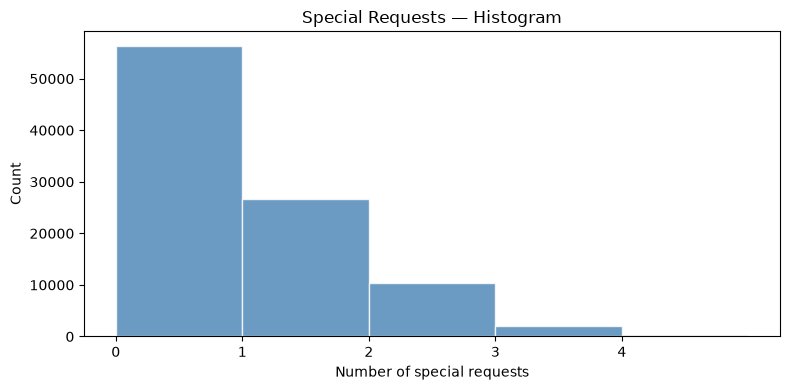

total_of_special_requests
0    0.589
1    0.278
2    0.109
3    0.021
4    0.003
5    0.000
Name: proportion, dtype: float64


In [ ]:
plt.figure(figsize=(8, 4))
plt.hist(df['total_of_special_requests'], bins=range(0, 6), color='steelblue', edgecolor='white', alpha=0.8)
plt.title('Special Requests — Histogram')
plt.xlabel('Number of special requests')
plt.ylabel('Count')
plt.xticks(range(0, 5))
plt.tight_layout()
plt.show()

print(df['total_of_special_requests'].value_counts(normalize=True).round(3))

Most guests make zero special requests (~58%). The count drops quickly as requests increase.

---
## Step 4: Categorical Distributions

For categorical columns, the key question is: what values exist, how many unique categories are there, and how are records distributed across them?

In [ ]:
ordinal_order = {
    'deposit_type': ['No Deposit', 'Refundable', 'Non Refund'],
    'customer_type': ['Transient', 'Transient-Party', 'Contract', 'Group'],
}

categorical_cols = ['hotel', 'deposit_type', 'market_segment', 'customer_type']

for col in categorical_cols:
    if col in ordinal_order:
        counts = df[col].value_counts().reindex(ordinal_order[col])
        print(f'--- {col} (logical order) ---')
    else:
        counts = df[col].value_counts()
        print(f'--- {col} ---')
    print(counts)
    print()

--- hotel ---
hotel
City Hotel      63676
Resort Hotel    32029
Name: count, dtype: int64

--- deposit_type (logical order) ---
deposit_type
No Deposit    83535
Refundable      131
Non Refund    12039
Name: count, dtype: int64

--- market_segment ---
market_segment
Online TA        45250
Offline TA/TO    19451
Groups           15896
Direct           10025
Corporate         4298
Complementary      607
Aviation           176
Undefined            2
Name: count, dtype: int64

--- customer_type (logical order) ---
customer_type
Transient          71999
Transient-Party    19970
Contract            3280
Group                456
Name: count, dtype: int64



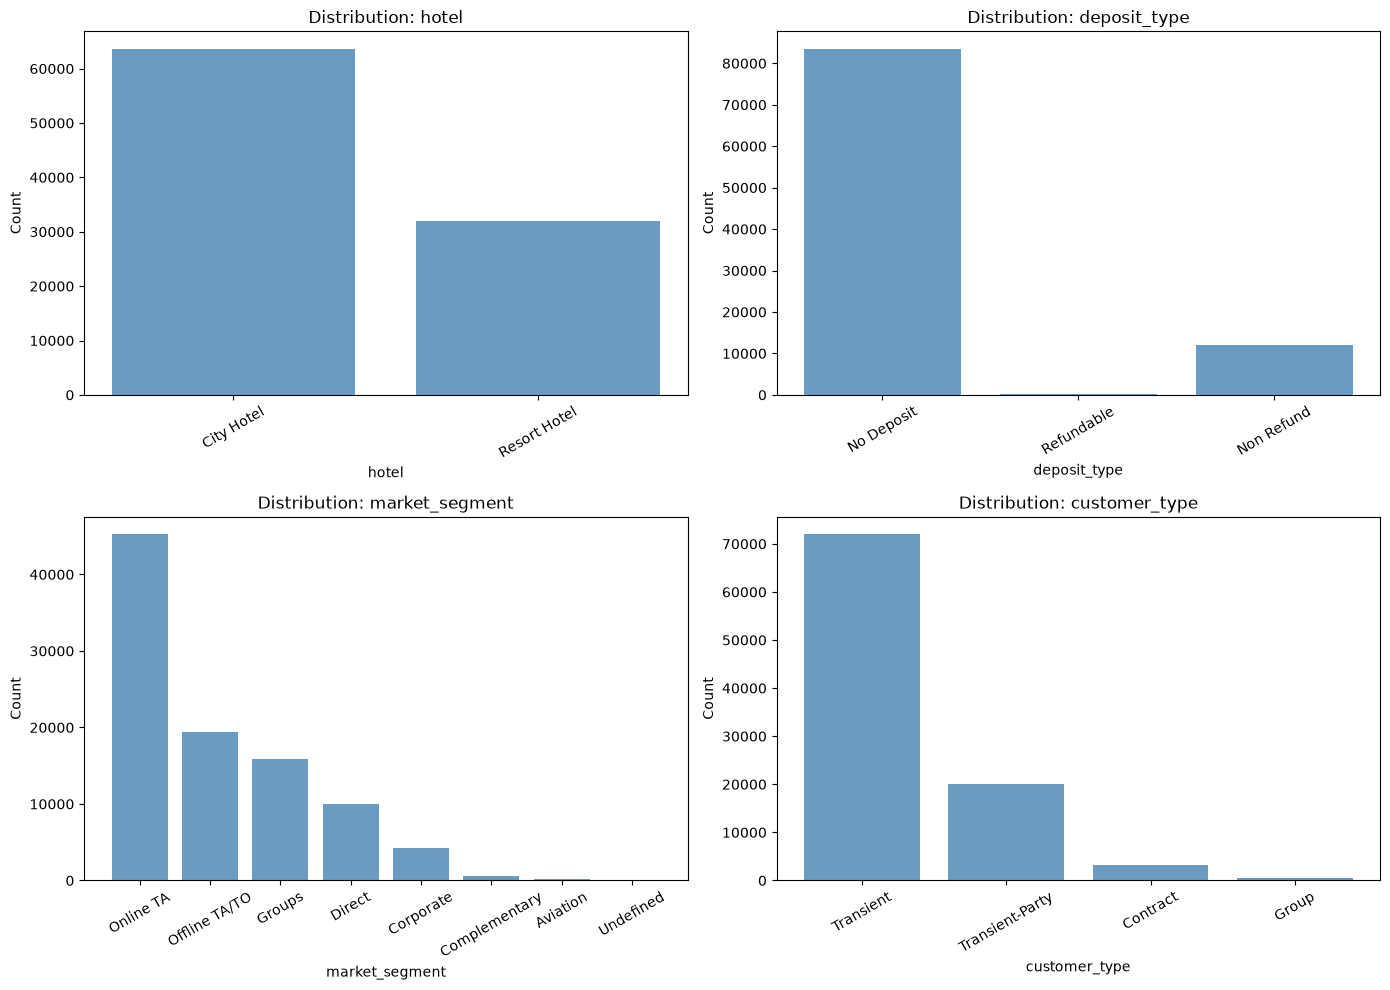

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    if col in ordinal_order:
        counts = df[col].value_counts().reindex(ordinal_order[col]).dropna()
    else:
        counts = df[col].value_counts().head(8)
    axes[i].bar(counts.index.astype(str), counts.values, color='steelblue', alpha=0.8)
    axes[i].set_title(f'Distribution: {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

**Observations:**
- `hotel`: City Hotel has more bookings than Resort Hotel (~67% vs ~33%)
- `deposit_type`: Most bookings have no deposit (~87%)
- `market_segment`: Online travel agents (Online TA) dominate
- `customer_type`: Transient (individual) bookings are the majority

In [ ]:
print('Unique values per column:')
for col in df.columns:
    print(f'  {col}: {df[col].nunique()}')

Unique values per column:
  hotel: 2
  is_canceled: 2
  lead_time: 469
  arrival_date_year: 3
  arrival_date_month: 12
  arrival_date_week_number: 53
  arrival_date_day_of_month: 31
  stays_in_weekend_nights: 16
  stays_in_week_nights: 32
  adults: 11
  children: 5
  babies: 5
  meal: 5
  country: 169
  market_segment: 8
  distribution_channel: 5
  is_repeated_guest: 2
  previous_cancellations: 13
  previous_bookings_not_canceled: 67
  reserved_room_type: 10
  assigned_room_type: 12
  booking_changes: 20
  deposit_type: 3
  agent: 321
  company: 338
  days_in_waiting_list: 124
  customer_type: 4
  adr: 7928
  required_car_parking_spaces: 5
  total_of_special_requests: 6
  reservation_status: 3
  reservation_status_date: 920
  total_nights: 42


> **High cardinality warning:** `country` has 169 unique codes, `agent` has hundreds of IDs, and `company` is almost entirely missing. These need special handling before modeling.

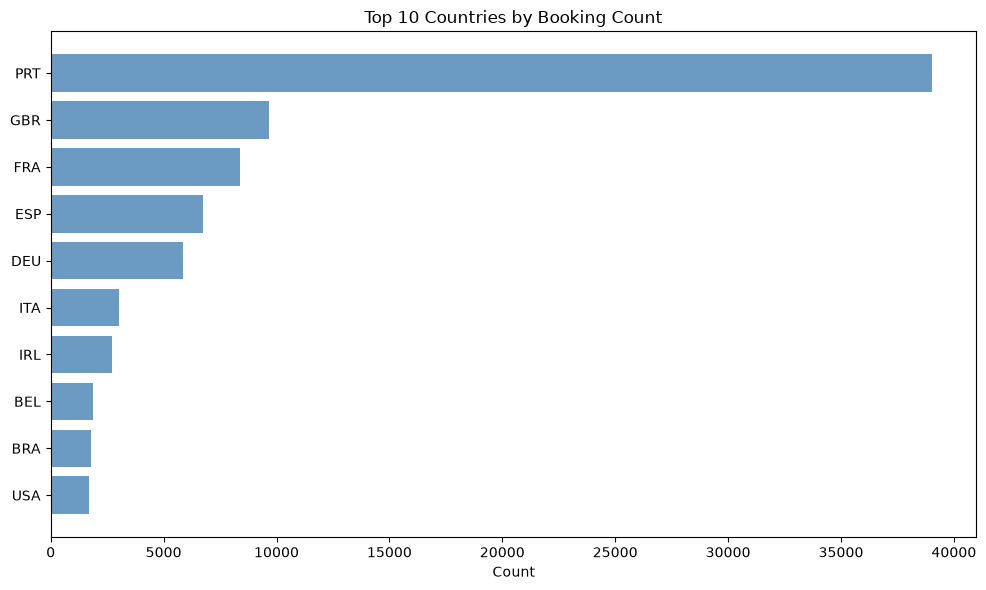

In [ ]:
plt.figure(figsize=(10, 6))
top_countries = df['country'].value_counts().head(10)
plt.barh(top_countries.index.astype(str), top_countries.values, color='steelblue', alpha=0.8)
plt.title('Top 10 Countries by Booking Count')
plt.xlabel('Count')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
cancel_by_hotel = df.groupby('hotel')['is_canceled'].agg(['mean', 'count'])
cancel_by_hotel.columns = ['cancel_rate', 'count']
cancel_by_hotel['cancel_rate'] = (cancel_by_hotel['cancel_rate'] * 100).round(1)
print(cancel_by_hotel)


              cancel_rate  count
hotel                           
City Hotel           41.9  63676
Resort Hotel         27.7  32029


City Hotel has a higher cancellation rate (~42%) than Resort Hotel (~28%).

---
## Step 5: Feature vs Target

Compare the target distribution across feature categories to find predictive signals.

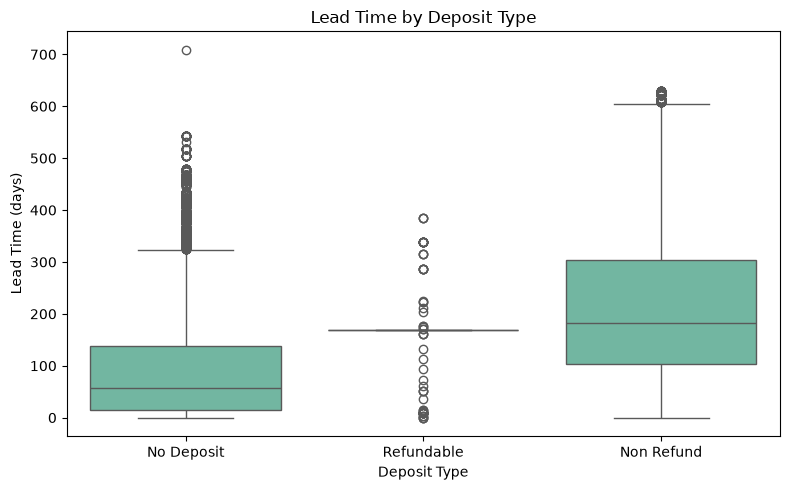

              median   mean  count
deposit_type                      
No Deposit      57.0   89.0  83535
Refundable     169.0  165.0    131
Non Refund     183.0  213.0  12039


In [ ]:
deposit_order = ['No Deposit', 'Refundable', 'Non Refund']

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x='deposit_type', y='lead_time', order=deposit_order, ax=ax)
ax.set_title('Lead Time by Deposit Type')
ax.set_xlabel('Deposit Type')
ax.set_ylabel('Lead Time (days)')
plt.tight_layout()
plt.show()

print(df.groupby('deposit_type')['lead_time']
        .agg(median='median', mean='mean', count='count').loc[deposit_order].round(0))

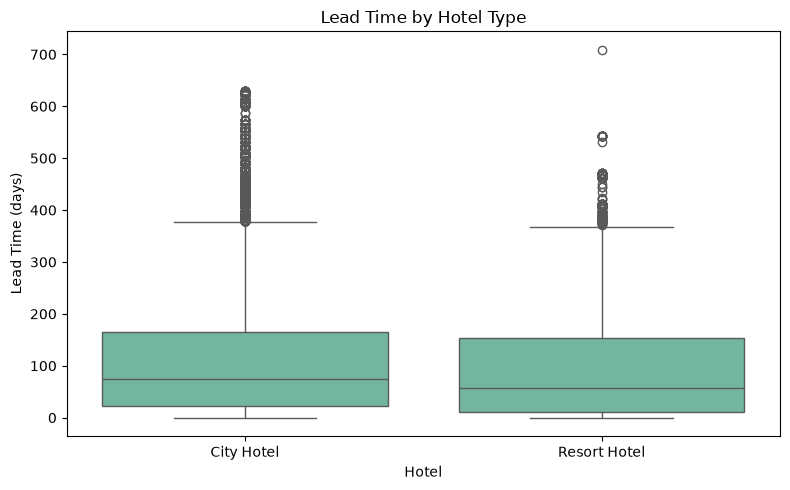

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x='hotel', y='lead_time', ax=ax)
ax.set_title('Lead Time by Hotel Type')
ax.set_xlabel('Hotel')
ax.set_ylabel('Lead Time (days)')
plt.tight_layout()
plt.show()

In [ ]:
cancel_rate = (df.groupby(['hotel', 'deposit_type'])['is_canceled'].mean().unstack()
               .reindex(columns=deposit_order) * 100)
print('Cancellation rate (%) by hotel and deposit type:')
print(cancel_rate.round(1))

Cancellation rate (%) by hotel and deposit type:
deposit_type  No Deposit  Refundable  Non Refund
hotel                                           
City Hotel          30.3        73.3        99.8
Resort Hotel        24.6        15.5        95.8


**Observation:** `Non Refund` deposits are almost always associated with canceled bookings (~99%). It is a strong signal, but also a reminder to check for **data leakage** (Step 8).

market_segment
Undefined        100.0
Groups            61.1
Online TA         36.7
Offline TA/TO     34.8
Aviation          24.4
Corporate         18.8
Direct            15.3
Complementary     11.9
Name: is_canceled, dtype: float64


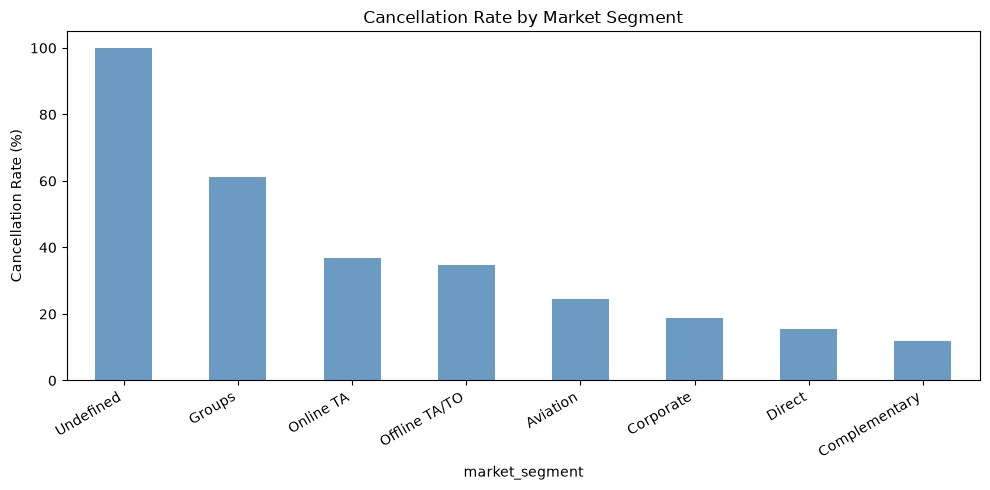

In [ ]:
seg_cancel = (df.groupby('market_segment')['is_canceled'].mean().sort_values(ascending=False) * 100)
print(seg_cancel.round(1))

plt.figure(figsize=(10, 5))
seg_cancel.plot(kind='bar', color='steelblue', alpha=0.8)
plt.title('Cancellation Rate by Market Segment')
plt.ylabel('Cancellation Rate (%)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

Groups and Online TA tend to have the highest cancellation rates, and as we noticed before, Oline TA and Online TA/TO are dominate on booking.

---
## Step 6: Correlation Matrix

The correlation coefficient measures the linear relationship between two numerical features (−1 to +1).

In [ ]:
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print('Numerical columns:', numerical_cols)

corr_matrix = df[numerical_cols].corr()
print('\nCorrelation with is_canceled:')
print(corr_matrix['is_canceled'].sort_values(ascending=False).round(3))

Numerical columns: ['is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'total_nights']

Correlation with is_canceled:
is_canceled                       1.000
lead_time                         0.303
previous_cancellations            0.111
adults                            0.062
days_in_waiting_list              0.056
adr                               0.045
stays_in_week_nights              0.031
total_nights                      0.024
arrival_date_week_number          0.012
arrival_date_year                 0.012
children                          0.005
stays_in_weekend_nights           0.003
arrival_date_day_of_month        -0.005
company      

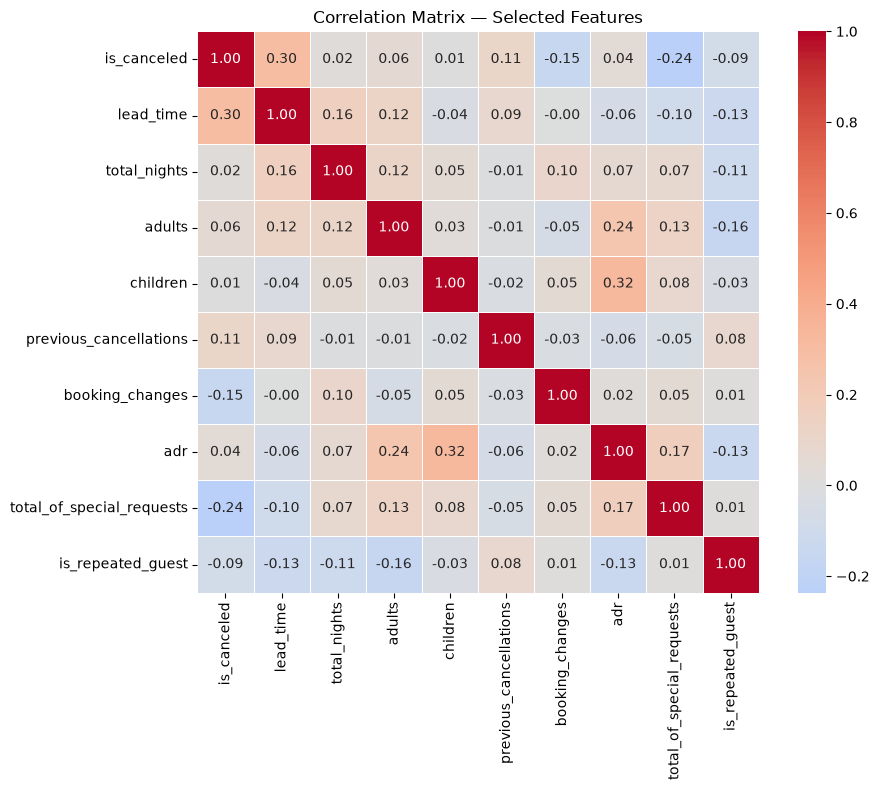

In [ ]:
cols_for_heatmap = ['is_canceled', 'lead_time', 'total_nights', 'adults', 'children',
    'previous_cancellations', 'booking_changes', 'adr', 'total_of_special_requests', 'is_repeated_guest']
corr_subset = df[cols_for_heatmap].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_subset, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('Correlation Matrix — Selected Features')
plt.tight_layout()
plt.show()

- `lead_time` has the strongest positive correlation with cancellation
- `total_of_special_requests` and `is_repeated_guest` correlate negatively
- `previous_cancellations` also correlates positively — past behavior predicts future behavior

---
## Step 7: Outliers & Skewness

**Skewness** measures asymmetry. |value| > 1 is notably skewed (positive = right tail).

In [ ]:
skew_cols = ['lead_time', 'adr', 'days_in_waiting_list', 'previous_cancellations']
skewness = df[skew_cols].skew().round(3)
print('Skewness per column (|value| > 1 = notably skewed):')
print(skewness)
print()
for col, skew in skewness.items():
    if abs(skew) > 1:
        direction = 'right (positive)' if skew > 0 else 'left (negative)'
        print(f'  {col}: skewed {direction} ({skew:.2f})')
    else:
        print(f'  {col}: approximately symmetric ({skew:.2f})')

Skewness per column (|value| > 1 = notably skewed):
lead_time                  1.337
adr                       12.482
days_in_waiting_list      12.391
previous_cancellations    24.705
dtype: float64

  lead_time: skewed right (positive) (1.34)
  adr: skewed right (positive) (12.48)
  days_in_waiting_list: skewed right (positive) (12.39)
  previous_cancellations: skewed right (positive) (24.70)


In [ ]:
Q1 = df['lead_time'].quantile(0.25)
Q3 = df['lead_time'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
outliers = df[df['lead_time'] > upper_bound]

print(f'IQR: {IQR:.0f} days')
print(f'Upper bound: {upper_bound:.0f} days')
print(f'Outliers: {len(outliers)} rows ({len(outliers)/len(df)*100:.1f}%)')
print(f'Outlier cancellation rate: {outliers["is_canceled"].mean():.1%}')
print(f'Overall cancellation rate:   {df["is_canceled"].mean():.1%}')

IQR: 143 days
Upper bound: 376 days
Outliers: 2282 rows (2.4%)
Outlier cancellation rate: 67.3%
Overall cancellation rate:   37.2%


> Outliers in `lead_time` are not necessarily errors. However, long-lead bookings cancel far more often — useful signal for the model.

---
## Step 8: Data Leakage & Feature Selection

Remove columns unavailable at prediction time or that directly reveal the answer:
- `reservation_status` — encodes canceled / check-out / no-show
- `reservation_status_date` — timestamp of the final status

For the baseline we use four numerical features flagged by EDA.

In [ ]:
leakage_cols = ['reservation_status', 'reservation_status_date']

print('Leakage check — reservation_status vs is_canceled:')
print(pd.crosstab(df['reservation_status'], df['is_canceled'], normalize='index').round(3))

feature_cols = ['lead_time', 'total_of_special_requests', 'previous_cancellations', 'adr']
print(f'\nBaseline features: {feature_cols}')

Leakage check — reservation_status vs is_canceled:
is_canceled           0    1
reservation_status          
Canceled            0.0  1.0
Check-Out           1.0  0.0
No-Show             0.0  1.0

Baseline features: ['lead_time', 'total_of_special_requests', 'previous_cancellations', 'adr']


---
## Step 9: Baseline Model

A **baseline** sets a performance floor. We use logistic regression with four numerical features, following the same workflow as the Telco Churn tutorial.

In [ ]:
model_df = df.drop(columns=leakage_cols).copy()
model_df['children'] = model_df['children'].fillna(0)

X = model_df[feature_cols]
y = model_df['is_canceled']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

baseline = LogisticRegression(random_state=RANDOM_SEED, max_iter=1000)
baseline.fit(X_train_sc, y_train)

y_pred = baseline.predict(X_test_sc)

dummy_accuracy = (y_test == 0).mean()
model_accuracy = accuracy_score(y_test, y_pred)

print(f'Test set size: {len(y_test)}  |  Cancellation rate: {y_test.mean():.3f}')
print(f'Dummy baseline (always predict 0): {dummy_accuracy:.3f}')
print(f'Logistic regression baseline:      {model_accuracy:.3f}')

Test set size: 19141  |  Cancellation rate: 0.372
Dummy baseline (always predict 0): 0.628
Logistic regression baseline:      0.710


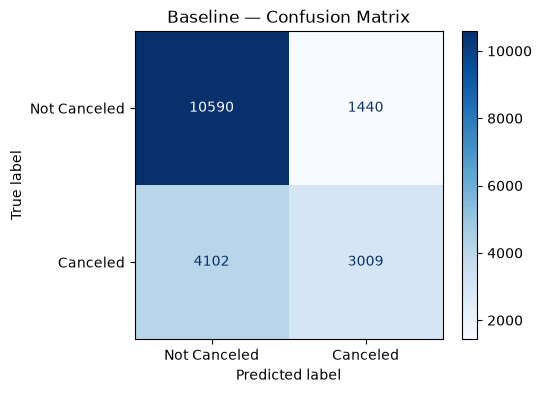

TN (correctly kept):       10590
FP (false alarm):          1440
FN (missed cancellation):  4102
TP (caught cancellation):  3009


In [ ]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=['Not Canceled', 'Canceled']).plot(ax=ax, cmap='Blues')
plt.title('Baseline — Confusion Matrix')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'TN (correctly kept):       {tn}')
print(f'FP (false alarm):          {fp}')
print(f'FN (missed cancellation):  {fn}')
print(f'TP (caught cancellation):  {tp}')

In [ ]:
coef_df = (pd.DataFrame({'feature': feature_cols, 'coefficient': baseline.coef_[0]})
           .sort_values('coefficient', ascending=False))
print('Learned coefficients (after scaling):')
print(coef_df.to_string(index=False))

Learned coefficients (after scaling):
                  feature  coefficient
   previous_cancellations     1.541144
                lead_time     0.597150
                      adr     0.335295
total_of_special_requests    -0.592808


**Interpreting the baseline:**
- Beats the dummy baseline (~63%) by a meaningful margin
- Coefficients match EDA: `lead_time` and `previous_cancellations` positive; `total_of_special_requests` negative
- Recall for canceled bookings is still moderate — a goal for future models

Next steps: add categorical features with one-hot encoding, handle missing values in `agent`/`country`, and evaluate with precision/recall/F1 (see `classification_metrics.ipynb`).

---
## Summary

1. **Shape** — ~95k rows, 32 columns
2. **Dtypes** — mix of numerical and categorical; `children`, `agent`, `company` have missing values
3. **Missing values** — `company` (~94%) mostly empty; `agent` (~14%) needs a strategy
4. **Distributions** — right-skewed `lead_time` and `adr`; most bookings have zero special requests
5. **Correlations** — `lead_time` and `previous_cancellations` correlate most with cancellation
6. **Issues** — high-cardinality `country`/`agent`, skewness, leakage in `reservation_status`
7. **Baseline** — logistic regression with 4 features beats the dummy model